# ResNet101 for Diabetic Foot Ulcer (DFU) Image Classification
This notebook trains a **ResNet101** model using transfer learning on DFU images with **5-Fold Cross-Validation**.  
Designed to run on **Kaggle GPU** environment.  
Uses the **same preprocessing & training configuration** as the DenseNet121 DFU notebook:
- **Optimizer**: Adam (lr = 1e-3)
- **Scheduler**: ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)
- **EarlyStopping**: patience = 7
- **Class weights**: balanced (sklearn)
- **Augmentation**: H-flip, V-flip, Rotation ±20°, Zoom ±20%, Brightness ±10%, Contrast ±10%

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# KAGGLE SETUP — Clone repo & install dependencies
# Run this cell FIRST on Kaggle to pull the project code and utilities.
# ══════════════════════════════════════════════════════════════════════════════
import os

REPO_URL    = 'https://github.com/csstudentkaum/KHOTAA.git'
BRANCH      = 'new-start'
REPO_DIR    = '/kaggle/working/KHOTAA'
WORKING_DIR = os.path.join(REPO_DIR, 'models', 'classification')

# Clone the repo (skip if already cloned)
if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} --single-branch {REPO_URL} {REPO_DIR}
    print(f"✓ Cloned {BRANCH} branch → {REPO_DIR}")
else:
    print(f"✓ Repo already exists at {REPO_DIR}")

# Change into the notebook's expected working directory
os.chdir(WORKING_DIR)
print(f"✓ Working directory: {os.getcwd()}")

# Install additional dependencies
!pip install roboflow -q
print("✓ Kaggle setup complete")

## 1. Imports & Configuration

In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import sys
import os
import random
import warnings
import json
warnings.filterwarnings('ignore')

# ── Numerical & Visualization ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import resnet101, ResNet101_Weights
from PIL import Image

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from datetime import datetime

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Project imports ───────────────────────────────────────────────────────────
# Works both locally (../utils) and on Kaggle (cloned repo structure)
sys.path.append('../')
sys.path.append('./')

import importlib
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils import checkpoint_manager, training_engine
importlib.reload(checkpoint_manager)
importlib.reload(training_engine)
from utils.checkpoint_manager import CheckpointManager
from utils.training_engine import (
    TrainingEngine, create_optimizer, create_scheduler,
    compute_balanced_class_weights
)
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_curve, plot_training_history
)

# ── Hyperparameters & Paths (aligned with DenseNet121 notebook) ───────────────
IMAGE_SIZE       = (224, 224)
BATCH_SIZE       = 32
EPOCHS           = 30
LEARNING_RATE    = 1e-3
FINE_TUNE_LR     = 1e-5
N_FOLDS          = 5

# ── Roboflow Dataset ──────────────────────────────────────────────────────────
from roboflow import Roboflow
rf = Roboflow(api_key="aOyWN2odFMV7P4HudwVJ")
project = rf.workspace("dfu-o28ut").project("dfu-kew1f-gzodp")
version = project.version(1)
dataset = version.download("folder")
DATASET_PATH = dataset.location + "/"

# ── Directories ───────────────────────────────────────────────────────────────
MODEL_NAME       = 'ResNet101'
RESULTS_DIR      = 'results'
CHECKPOINT_DIR   = 'checkpoints'

print("✓ Imports complete (modules reloaded)")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Image size      : {IMAGE_SIZE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Dataset path    : {DATASET_PATH}")

✓ Imports complete (modules reloaded)
PyTorch version: 2.8.0
CUDA available: False


## 2. Load & Explore Dataset

In [ ]:
# ── Verify dataset directory structure ────────────────────────────────────────
print('Dataset root contents:')
for entry in sorted(os.listdir(DATASET_PATH)):
    full = os.path.join(DATASET_PATH, entry)
    kind = 'DIR' if os.path.isdir(full) else 'FILE'
    print(f'  [{kind}] {entry}')

# ── Load dataset (auto-detects train/valid/val/test splits) ──────────────────
loader = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f"\nClasses: {classes}")
print(f"Number of classes: {num_classes}")

# ── Print full structure overview ─────────────────────────────────────────────
loader.print_structure()

# ── Initialize preprocessing ─────────────────────────────────────────────────
preprocessor = DFUPreprocessing()
train_transform    = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

# ── PyTorch Dataset class ─────────────────────────────────────────────────────
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# ── Prepare data for cross-validation (train + valid combined) ────────────────
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# ── Test set (untouched until final evaluation) ──────────────────────────────
X_test, y_test = loader.load_split_paths('test')
test_dataset = DFUDataset(X_test, y_test, transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Initialize 5-fold stratified cross-validation ────────────────────────────
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f"\nTotal training samples (train+valid): {len(X_all)}")
print(f"Test samples: {len(X_test)}")
print("✓ Dataset loaded and ready for 5-fold cross-validation")

[DatasetLoader] Root: /Users/manaralharbi/Desktop/KHOTAA/dfu-dataset-annotated-into-4-classes
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Classes: ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Number of classes: 4
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 9639 images
[DatasetLoader] Split 'valid': 282 images
[DatasetLoader] Split 'test': 141 images

Total training samples (train+valid): 9921
Test samples: 141
✓ Dataset loaded and ready for 5-fold cross-validation


In [ ]:
# ── Display sample images from training set ───────────────────────────────────
loader.show_samples('train', n_cols=4, n_rows=2, title='Training Set — Sample Images')

In [ ]:
# ── Class distribution for ALL splits (before augmentation) ───────────────────
loader.plot_all_splits_distribution()

# ── Detailed class distribution for training data ─────────────────────────────
preprocessor.plot_class_distribution(
    y_all, classes,
    title='Class Distribution — Training + Validation (Before Augmentation)'
)
print(f"Total training+val samples: {len(y_all)}")
print(f"Class counts: { {classes[i]: int(np.sum(y_all == i)) for i in range(num_classes)} }")

## 3. Data Preprocessing & Augmentation Visualization

In [ ]:
# ── Visualise augmentation on a single image ──────────────────────────────────
sample_path = X_train[0]
preprocessor.show_augmentation_samples(
    sample_path, n_samples=8,
    title='Data Augmentation Samples (single image)'
)

# ── Preprocessing sample results: Original → Resized → Augmented+Normalised ──
preprocessor.show_preprocessing_samples(
    X_train, y_train, classes,
    n_samples=4,
    title='Preprocessing Pipeline — Before Training'
)

# ── Class distribution after augmentation (simulated) ─────────────────────────
# Since PyTorch applies augmentation on-the-fly, the class counts remain the
# same.  We show this comparison to confirm augmentation does NOT change the
# class balance — it only adds variety within each class.
preprocessor.plot_class_distribution_comparison(
    y_all, y_all,
    classes,
    title='Class Distribution — Before vs After Augmentation\n(Online augmentation keeps counts identical)'
)
print("Note: PyTorch applies augmentation on-the-fly during training,")
print("so class counts remain the same. Augmentation adds visual variety, not extra samples.")

Device: cpu

✓ ResNet101 model created
Input size: 224x224
Output classes: 4
Final FC layer: Linear(in_features=2048, out_features=4, bias=True)


## 4. Build Model (Transfer Learning)

In [ ]:
# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Create ResNet101 model ────────────────────────────────────────────────────
def create_resnet101_model(num_classes=4, pretrained=True):
    """
    Create ResNet101 model for DFU classification.
    Uses ImageNet pretrained weights with custom classification head.
    
    Architecture:
        ResNet101 backbone (frozen or trainable)
        → AdaptiveAvgPool2d → Flatten
        → Linear(2048 → num_classes)
    
    Args:
        num_classes: Number of output classes
        pretrained: Use ImageNet pretrained weights
    
    Returns:
        ResNet101 model configured for DFU classification
    """
    if pretrained:
        model = models.resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
    else:
        model = models.resnet101(weights=None)
    
    # Replace final FC layer: Linear(2048 → num_classes)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

# ── Test model creation ───────────────────────────────────────────────────────
test_model = create_resnet101_model(num_classes=num_classes)
total_params     = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print(f"\n✓ ResNet101 model created")
print(f"Input size       : 224×224")
print(f"Output classes   : {num_classes}")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Final FC layer   : {test_model.fc}")
del test_model  # free memory

## 5. Class Weights

Compute balanced class weights (same approach as DenseNet121 notebook) to handle class imbalance.

In [ ]:
# ── Compute balanced class weights (same as DenseNet121 notebook) ─────────────
class_weights_tensor = compute_balanced_class_weights(y_all, device=device)

# ── Create weighted loss function ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f"\n✓ CrossEntropyLoss with balanced class weights")
print(f"  Weights: {class_weights_tensor.cpu().numpy()}")
print(f"  Classes: {classes}")

## 6. Training (5-Fold Cross-Validation)

Training configuration (aligned with DenseNet121 notebook):
- **Optimizer**: Adam (lr = 1e-3)
- **Scheduler**: ReduceLROnPlateau (factor=0.3, patience=3, min_lr=1e-7)
- **EarlyStopping**: patience = 7, monitors val_loss, restores best weights
- **Loss**: CrossEntropyLoss with balanced class weights
- **Epochs**: 30 max per fold

In [ ]:
# ── 5-Fold Cross-Validation Training ──────────────────────────────────────────
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
    print(f"\n{'='*60}\nFOLD {fold}/{N_FOLDS}\n{'='*60}")
    
    # Prepare fold data
    X_train_fold = X_all[train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold   = X_all[val_idx]
    y_val_fold   = y_all[val_idx]
    
    train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
    val_dataset   = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Create fresh model for this fold
    model = create_resnet101_model(num_classes=num_classes, pretrained=True)
    model = model.to(device)
    
    # Setup optimizer: Adam with lr=1e-3 (matching DenseNet121 notebook)
    optimizer = create_optimizer(model, optimizer_type='adam', lr=LEARNING_RATE, weight_decay=1e-4)
    
    # Setup scheduler: ReduceLROnPlateau (matching DenseNet121 notebook)
    scheduler = create_scheduler(optimizer, scheduler_type='plateau',
                                 gamma=0.3, patience=3, min_lr=1e-7)
    
    # Checkpoint manager
    checkpoint_manager_fold = CheckpointManager(
        base_dir=CHECKPOINT_DIR,
        experiment_name=f'resnet101_fold{fold}'
    )
    
    # Training engine
    engine = TrainingEngine(model=model, device=device)

    # Train with early stopping (patience=7)
    history = engine.train(
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=EPOCHS,
        scheduler=scheduler,
        checkpoint_manager=checkpoint_manager_fold,
        early_stopping_patience=7,
        use_early_stopping=True,
        verbose=True
    )
    
    # Store results
    best_val_acc = max(history['val_acc'])
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'final_val_acc': history['val_acc'][-1],
        'stopped_epoch': history['stopped_epoch'],
        'history': history
    })
    print(f"Fold {fold} — Best Acc: {best_val_acc*100:.2f}% (stopped at epoch {history['stopped_epoch']})")

# ── Cross-validation summary ─────────────────────────────────────────────────
avg_acc    = np.mean([r['best_val_acc'] for r in fold_results])
std_acc    = np.std([r['best_val_acc'] for r in fold_results])
avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])

print(f"\n{'='*60}")
print(f"5-FOLD CROSS-VALIDATION RESULTS")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"\nIndividual Fold Results:")
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
print(f"{'='*60}")


FOLD 1/5
Created SGD optimizer: lr=0.001, momentum=0.8, weight_decay=0.0001
Training on: cpu

Epoch 1/30


Evaluating: 100%|██████████| 63/63 [06:55<00:00,  6.60s/it, loss=1.1505, acc=53.30%]


Learning Rate: 0.001000

Epoch 1 Results:
   Train Loss: 1.2725 | Train Acc: 43.36%
   Val Loss:   1.1742 | Val Acc:   53.30%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold1/fold_1/checkpoint_epoch_1.pth
SUCCESS: Best model saved: checkpoints/resnet101_fold1/fold_1/best_accuracy.pt
New best model! Val Acc: 53.30%

Epoch 2/30


Evaluating: 100%|██████████| 63/63 [06:45<00:00,  6.44s/it, loss=0.7342, acc=61.81%]


Learning Rate: 0.001000

Epoch 2 Results:
   Train Loss: 1.0646 | Train Acc: 56.24%
   Val Loss:   0.9748 | Val Acc:   61.81%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold1/fold_1/checkpoint_epoch_2.pth
SUCCESS: Best model saved: checkpoints/resnet101_fold1/fold_1/best_accuracy.pt
New best model! Val Acc: 61.81%

Epoch 3/30


...

Evaluating: 100%|██████████| 62/62 [07:33<00:00,  7.32s/it, loss=0.7897, acc=91.18%]


Learning Rate: 0.000010

Epoch 27 Results:
   Train Loss: 0.2981 | Train Acc: 89.63%
   Val Loss:   0.2855 | Val Acc:   91.18%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold4/fold_1/checkpoint_epoch_27.pth

Epoch 28/30


Evaluating: 100%|██████████| 62/62 [07:32<00:00,  7.30s/it, loss=0.7696, acc=91.08%]


Learning Rate: 0.000010

Epoch 28 Results:
   Train Loss: 0.2993 | Train Acc: 89.50%
   Val Loss:   0.2848 | Val Acc:   91.08%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold4/fold_1/checkpoint_epoch_28.pth

Epoch 29/30


Training:  15%|█▌        | 38/249 [06:11<31:36,  8.99s/it, loss=0.3188, acc=90.38%]

In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║ CLEAN UP OLD CHECKPOINTS (Kaggle disk quota fix)                        ║
# ╚════════════════════════════════════════════════════════════════════════════╝
import shutil, os
ckpt_dir = './checkpoints'
if os.path.exists(ckpt_dir):
    shutil.rmtree(ckpt_dir)
    print('✓ Old checkpoints deleted.')
else:
    print('No checkpoints directory found.')

## 6.1 Resume Training (if interrupted)

In [ ]:
# ── Resume Training from Last Checkpoint ──────────────────────────────────────
print("="*60)
print("RESUMING TRAINING FROM CHECKPOINT")
print("="*60)

completed_folds = len(fold_results)
next_fold_to_train = completed_folds + 1

print(f"\nFold results collected so far: {completed_folds}/{N_FOLDS}")
print(f"Next fold to train: {next_fold_to_train}")

if next_fold_to_train <= N_FOLDS:
    print(f"\n{'='*60}")
    print(f"CONTINUING TRAINING FROM FOLD {next_fold_to_train}")
    print(f"{'='*60}")
    
    for fold_num, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
        if fold_num < next_fold_to_train:
            continue
        
        print(f"\n{'='*60}\nFOLD {fold_num}/{N_FOLDS}\n{'='*60}")
        
        X_train_fold = X_all[train_idx]
        y_train_fold = y_all[train_idx]
        X_val_fold   = X_all[val_idx]
        y_val_fold   = y_all[val_idx]
        
        train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
        val_dataset   = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)
        
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        
        model = create_resnet101_model(num_classes=num_classes, pretrained=True)
        model = model.to(device)
        
        optimizer = create_optimizer(model, optimizer_type='adam', lr=LEARNING_RATE, weight_decay=1e-4)
        scheduler = create_scheduler(optimizer, scheduler_type='plateau',
                                     gamma=0.3, patience=3, min_lr=1e-7)
        checkpoint_manager_fold = CheckpointManager(
            base_dir=CHECKPOINT_DIR,
            experiment_name=f'resnet101_fold{fold_num}'
        )
        engine = TrainingEngine(model=model, device=device)
        
        history = engine.train(
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            num_epochs=EPOCHS,
            scheduler=scheduler,
            checkpoint_manager=checkpoint_manager_fold,
            early_stopping_patience=7,
            use_early_stopping=True,
            verbose=True
        )
        
        best_val_acc = max(history['val_acc'])
        fold_results.append({
            'fold': fold_num,
            'best_val_acc': best_val_acc,
            'final_val_acc': history['val_acc'][-1],
            'stopped_epoch': history['stopped_epoch'],
            'history': history
        })
        print(f"Fold {fold_num} — Best Acc: {best_val_acc*100:.2f}% (stopped at epoch {history['stopped_epoch']})")
    
    avg_acc    = np.mean([r['best_val_acc'] for r in fold_results])
    std_acc    = np.std([r['best_val_acc'] for r in fold_results])
    avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])
    
    print(f"\n{'='*60}")
    print(f"5-FOLD CROSS-VALIDATION RESULTS (COMPLETE)")
    print(f"{'='*60}")
    print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
    print(f"Average Epochs: {avg_epochs:.1f}")
    for r in fold_results:
        print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
    print(f"{'='*60}")
else:
    print("\n✓ All 5 folds have been completed!")
    avg_acc    = np.mean([r['best_val_acc'] for r in fold_results])
    std_acc    = np.std([r['best_val_acc'] for r in fold_results])
    avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])
    
    print(f"\n{'='*60}")
    print(f"5-FOLD CROSS-VALIDATION RESULTS")
    print(f"{'='*60}")
    print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
    print(f"Average Epochs: {avg_epochs:.1f}")
    for r in fold_results:
        print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
    print(f"{'='*60}")

RESUMING TRAINING FROM CHECKPOINT

Fold results collected so far: 3/5
Completed folds: 3
Next fold to train: 4

CONTINUING TRAINING FROM FOLD 4

FOLD 4/5
Created SGD optimizer: lr=0.001, momentum=0.8, weight_decay=0.0001
Training on: cpu

Epoch 1/30
Created SGD optimizer: lr=0.001, momentum=0.8, weight_decay=0.0001
Training on: cpu

Epoch 1/30


Evaluating: 100%|██████████| 62/62 [06:13<00:00,  6.02s/it, loss=1.1813, acc=50.60%]



Learning Rate: 0.001000

Epoch 1 Results:
   Train Loss: 1.2920 | Train Acc: 41.00%
   Val Loss:   1.1974 | Val Acc:   50.60%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold4/fold_1/checkpoint_epoch_1.pth
SUCCESS: Best model saved: checkpoints/resnet101_fold4/fold_1/best_accuracy.pt
New best model! Val Acc: 50.60%

Epoch 2/30
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold4/fold_1/checkpoint_epoch_1.pth
SUCCESS: Best model saved: checkpoints/resnet101_fold4/fold_1/best_accuracy.pt
New best model! Val Acc: 50.60%

Epoch 2/30


Evaluating: 100%|██████████| 62/62 [07:01<00:00,  6.79s/it, loss=0.9838, acc=60.69%]



Learning Rate: 0.001000

Epoch 2 Results:
   Train Loss: 1.0708 | Train Acc: 56.39%
   Val Loss:   0.9895 | Val Acc:   60.69%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold4/fold_1/checkpoint_epoch_2.pth
SUCCESS: Best model saved: checkpoints/resnet101_fold4/fold_1/best_accuracy.pt
New best model! Val Acc: 60.69%

Epoch 3/30
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold4/fold_1/checkpoint_epoch_2.pth
SUCCESS: Best model saved: checkpoints/resnet101_fold4/fold_1/best_accuracy.pt
New best model! Val Acc: 60.69%

Epoch 3/30


...

Learning Rate: 0.000010

Epoch 28 Results:
   Train Loss: 0.3040 | Train Acc: 89.57%
   Val Loss:   0.3267 | Val Acc:   89.16%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold5/fold_1/checkpoint_epoch_28.pth

Epoch 29/30
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold5/fold_1/checkpoint_epoch_28.pth

Epoch 29/30


Evaluating: 100%|██████████| 62/62 [06:49<00:00,  6.60s/it, loss=1.6130, acc=89.36%]



Learning Rate: 0.000010

Epoch 29 Results:
   Train Loss: 0.3097 | Train Acc: 88.96%
   Val Loss:   0.3111 | Val Acc:   89.36%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold5/fold_1/checkpoint_epoch_29.pth
SUCCESS: Best model saved: checkpoints/resnet101_fold5/fold_1/best_accuracy.pt
New best model! Val Acc: 89.36%

Epoch 30/30
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold5/fold_1/checkpoint_epoch_29.pth
SUCCESS: Best model saved: checkpoints/resnet101_fold5/fold_1/best_accuracy.pt
New best model! Val Acc: 89.36%

Epoch 30/30


Evaluating: 100%|██████████| 62/62 [06:50<00:00,  6.62s/it, loss=1.7532, acc=88.96%]



Learning Rate: 0.000001

Epoch 30 Results:
   Train Loss: 0.3087 | Train Acc: 89.15%
   Val Loss:   0.3255 | Val Acc:   88.96%
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold5/fold_1/checkpoint_epoch_30.pth

SUCCESS: Training Complete!
Completed all 30 epochs
Best Validation Accuracy: 89.36%

Fold 5 - Best Acc: 89.36% (stopped at epoch 30)

5-FOLD CROSS-VALIDATION RESULTS (COMPLETE)
Mean Accuracy: 91.05% ± 0.98%
Average Epochs: 29.2

Individual Fold Results:
  Fold 1: 91.64% (epoch 30)
  Fold 2: 90.62% (epoch 30)
  Fold 3: 91.43% (epoch 30)
  Fold 4: 92.19% (epoch 26)
  Fold 5: 89.36% (epoch 30)
SUCCESS: Checkpoint saved: checkpoints/resnet101_fold5/fold_1/checkpoint_epoch_30.pth

SUCCESS: Training Complete!
Completed all 30 epochs
Best Validation Accuracy: 89.36%

Fold 5 - Best Acc: 89.36% (stopped at epoch 30)

5-FOLD CROSS-VALIDATION RESULTS (COMPLETE)
Mean Accuracy: 91.05% ± 0.98%
Average Epochs: 29.2

Individual Fold Results:
  Fold 1: 91.64% (epoch 30)
  Fold 2: 90.62% (epo

## 7. Training Curves & Evaluation Plots

✓ Results directory created: results/resnet101
✓ Directory verified: /Users/manaralharbi/Desktop/KHOTAA/models/classification/results/resnet101
✓ Loaded best model from checkpoints/resnet101_fold4/fold_1/best_accuracy.pt
✓ Loaded best model from checkpoints/resnet101_fold4/fold_1/best_accuracy.pt


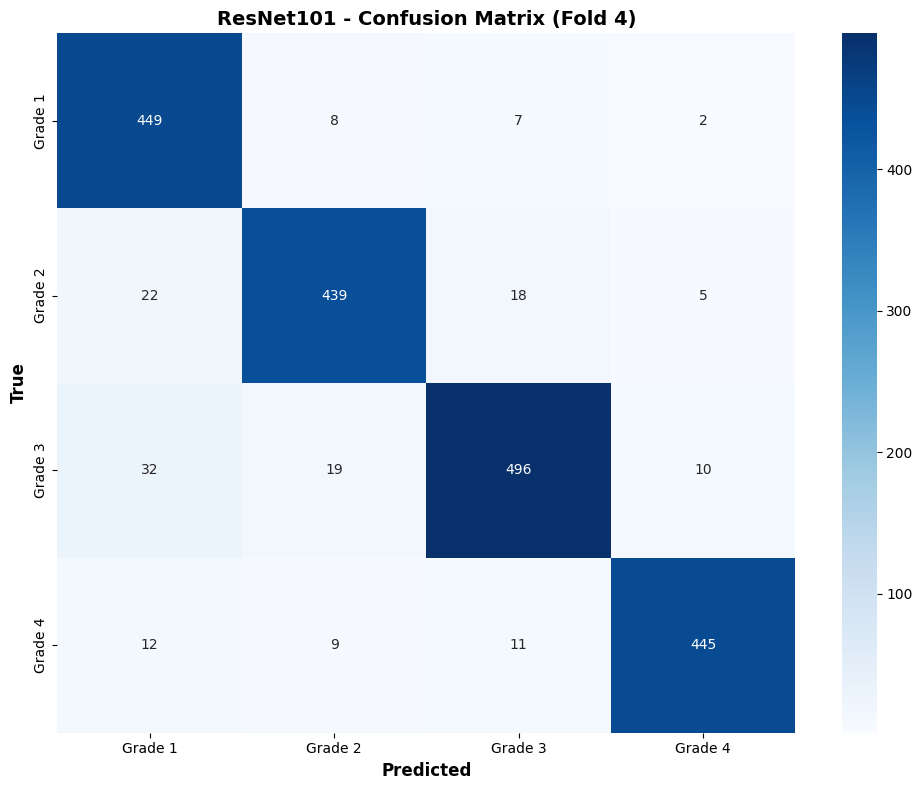


⏳ Generating aggregated confusion matrix across all folds...
  ✓ Fold 1 processed
  ✓ Fold 1 processed
  ✓ Fold 2 processed
  ✓ Fold 2 processed
  ✓ Fold 3 processed
  ✓ Fold 3 processed
  ✓ Fold 4 processed
  ✓ Fold 4 processed
  ✓ Fold 5 processed
  ✓ Fold 5 processed


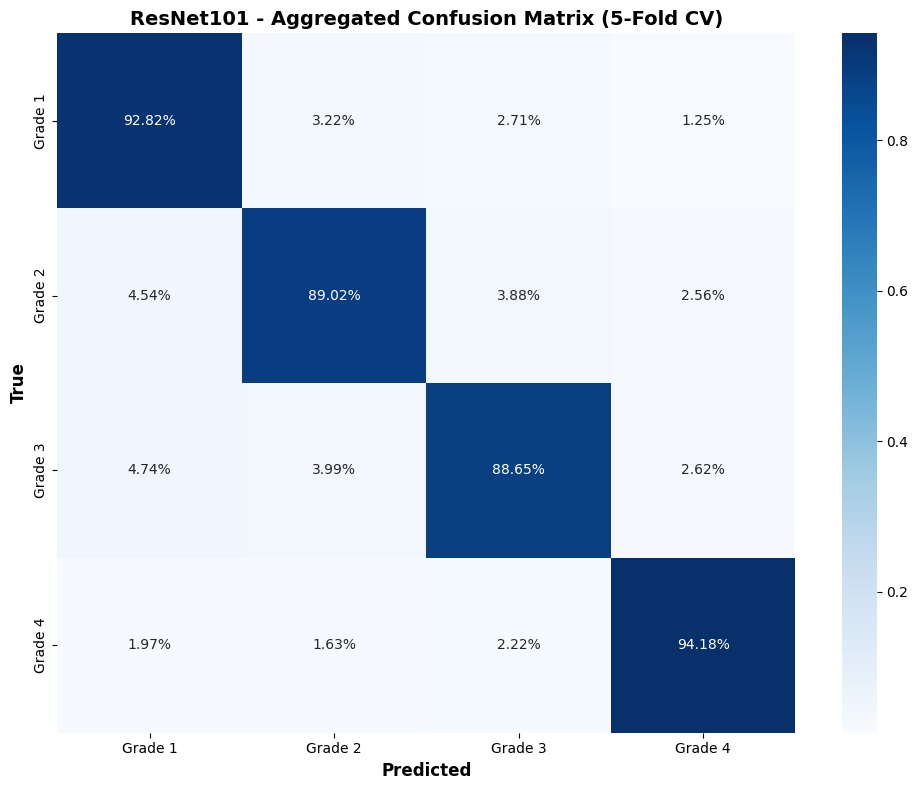

✓ Aggregated confusion matrix saved (9921 total predictions)


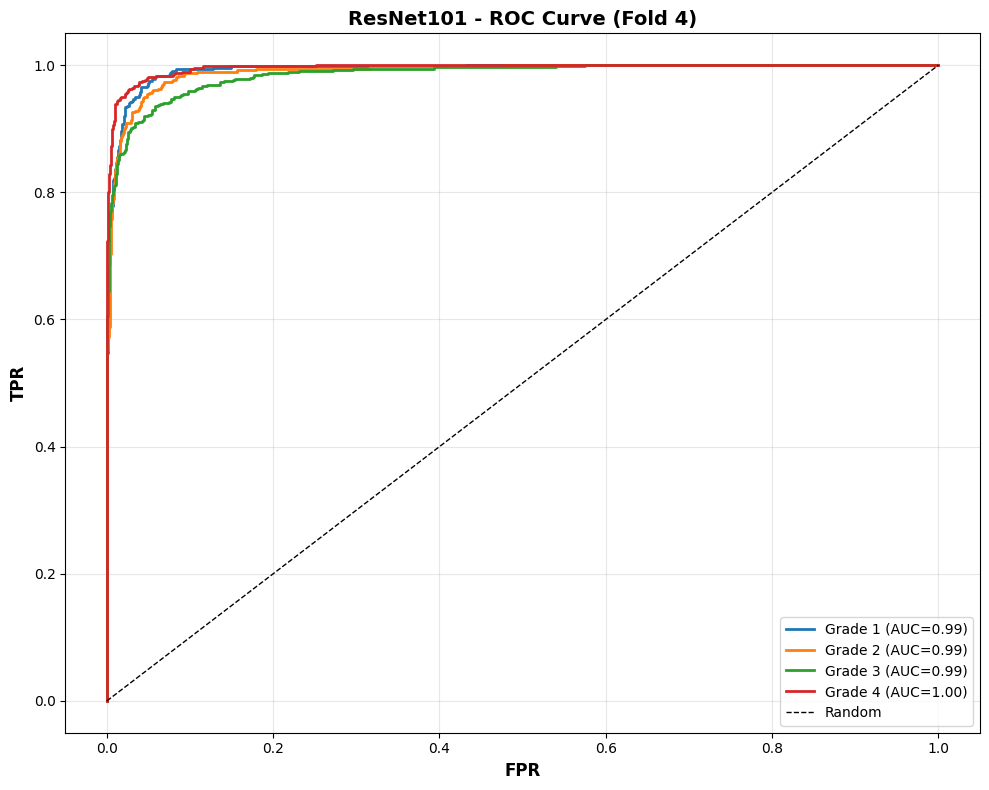

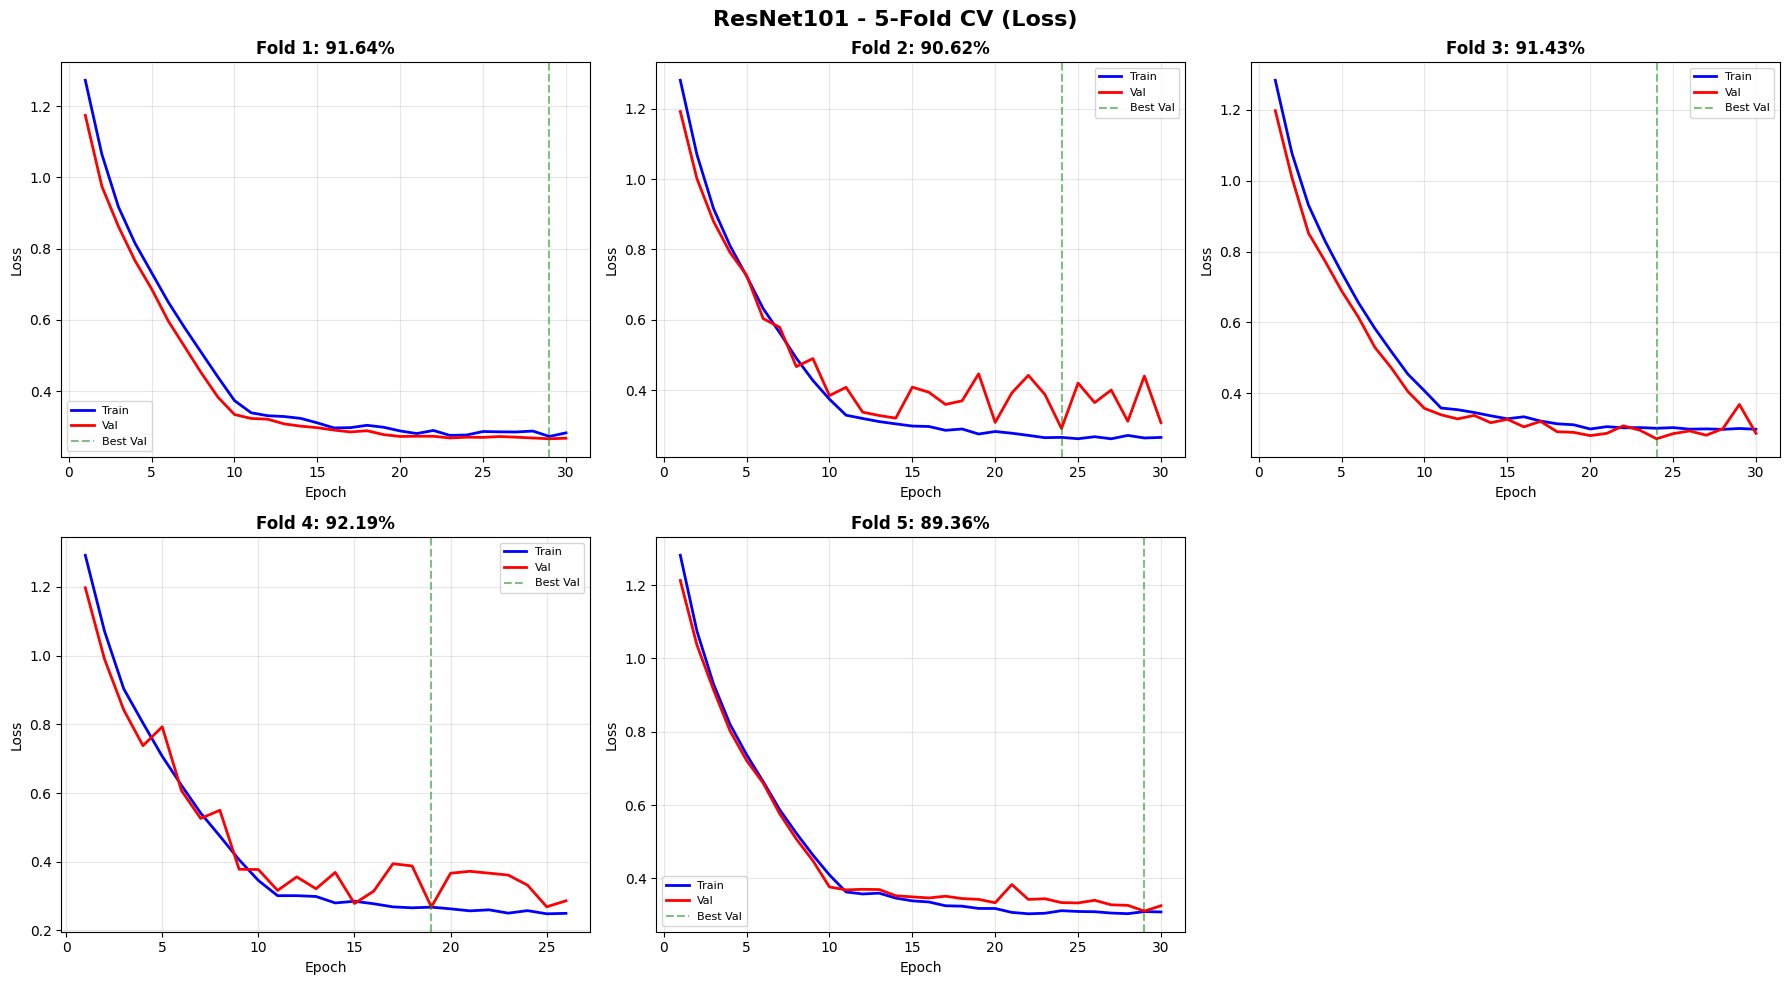

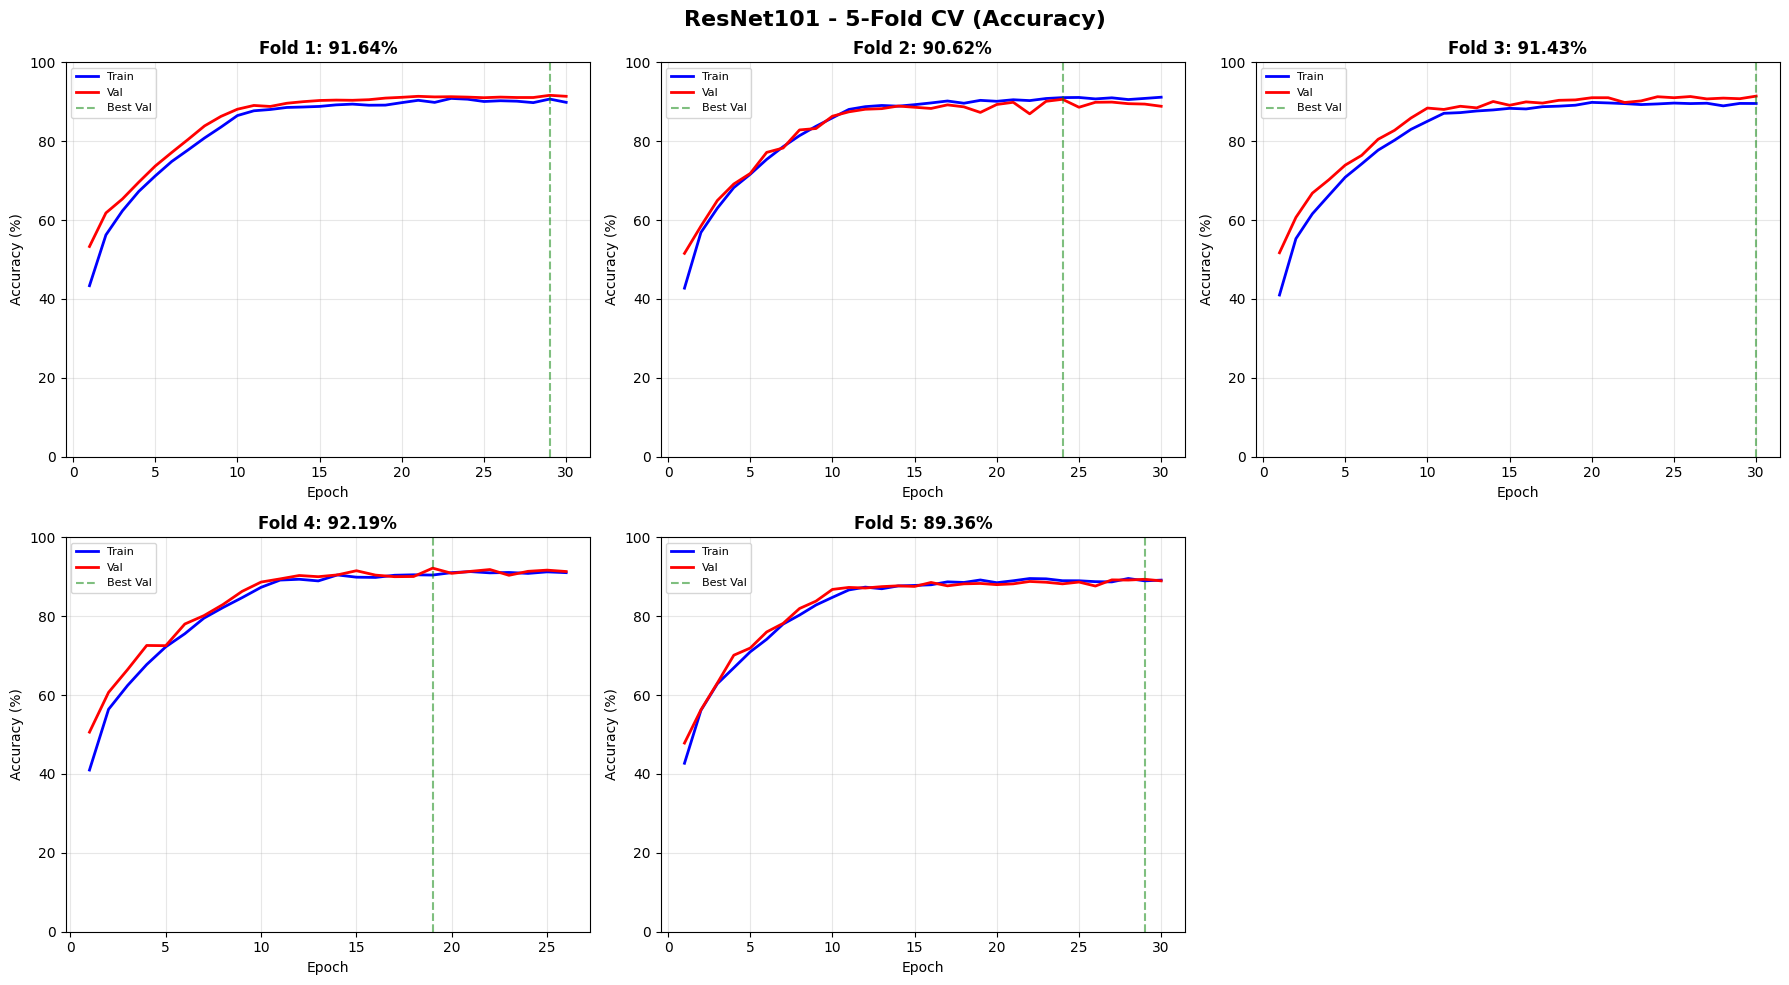


ResNet101 CROSS-VALIDATION SUMMARY
Mean Accuracy: 91.05% ± 0.98%
Best Fold: 4 (92.19%)
Average Epochs: 29.2

Results saved to: results/resnet101/resnet101_cv_results.json


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
DPI = 300
PLOT_CONFIG = {
    'cm':      {'size': (10, 8), 'cmap': 'Blues'},
    'roc':     {'size': (10, 8), 'lw': 2},
    'history': {'size': (18, 10)},
}
FONT = {'title': 14, 'label': 12, 'legend': 10, 'tick': 10}

# Create model-specific results directory
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
os.makedirs(model_results_dir, exist_ok=True)
print(f"✓ Results directory: {os.path.abspath(model_results_dir)}")

# ══════════════════════════════════════════════════════════════════════════════
# GET BEST FOLD & LOAD BEST MODEL
# ══════════════════════════════════════════════════════════════════════════════
best_fold_idx = np.argmax([r['best_val_acc'] for r in fold_results])
best_fold_num = fold_results[best_fold_idx]['fold']

fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx]
val_dataset = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

checkpoint_path = f'{CHECKPOINT_DIR}/resnet101_fold{best_fold_num}/fold_1/best_accuracy.pt'
if os.path.exists(checkpoint_path):
    model = create_resnet101_model(num_classes=num_classes, pretrained=False)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device).eval()
    print(f"✓ Loaded best model from {checkpoint_path}")
else:
    print(f"⚠ Warning: Checkpoint not found at {checkpoint_path}")

# ══════════════════════════════════════════════════════════════════════════════
# GET PREDICTIONS (BEST FOLD)
# ══════════════════════════════════════════════════════════════════════════════
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions  = np.concatenate(all_preds)
true_labels  = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

# ══════════════════════════════════════════════════════════════════════════════
# 1. CONFUSION MATRIX (BEST FOLD — RAW COUNTS)
# ══════════════════════════════════════════════════════════════════════════════
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm, annot=True, fmt='d', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (Fold {best_fold_num})',
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 2. AGGREGATED CONFUSION MATRIX (ALL 5 FOLDS)
# ══════════════════════════════════════════════════════════════════════════════
print("\n⏳ Generating aggregated confusion matrix across all folds...")
cm_aggregated = np.zeros((num_classes, num_classes), dtype=int)

for fold_idx, (train_idx_f, val_idx_f) in enumerate(fold_splits, 1):
    val_dataset_fold = DFUDataset(X_all[val_idx_f], y_all[val_idx_f], transform=val_test_transform)
    val_loader_fold  = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    fold_cp = f'{CHECKPOINT_DIR}/resnet101_fold{fold_idx}/fold_1/best_accuracy.pt'
    if os.path.exists(fold_cp):
        model_f = create_resnet101_model(num_classes=num_classes, pretrained=False)
        model_f.load_state_dict(torch.load(fold_cp, map_location=device))
        model_f = model_f.to(device).eval()
        
        fold_preds, fold_labels = [], []
        with torch.no_grad():
            for inp, lbl in val_loader_fold:
                out = model_f(inp.to(device))
                fold_preds.append(torch.max(out, 1)[1].cpu().numpy())
                fold_labels.append(lbl.numpy())
        
        fp = np.concatenate(fold_preds)
        fl = np.concatenate(fold_labels)
        cm_aggregated += confusion_matrix(fl, fp, labels=range(num_classes))
        print(f"  ✓ Fold {fold_idx} processed")
        del model_f
    else:
        print(f"  ⚠ Fold {fold_idx} checkpoint not found, skipping")

cm_aggregated_norm = cm_aggregated.astype('float') / cm_aggregated.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm_aggregated_norm, annot=True, fmt='.2%', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} — Aggregated Confusion Matrix (5-Fold CV)',
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix_aggregated.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print(f"✓ Aggregated CM saved ({cm_aggregated.sum()} total predictions)")

# ══════════════════════════════════════════════════════════════════════════════
# 3. ROC CURVE (BEST FOLD)
# ══════════════════════════════════════════════════════════════════════════════
y_true_bin = label_binarize(true_labels, classes=range(num_classes))
fig, ax = plt.subplots(figsize=PLOT_CONFIG['roc']['size'])

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, linewidth=PLOT_CONFIG['roc']['lw'],
            label=f'{classes[i]} (AUC={auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('TPR', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} — ROC Curve (Fold {best_fold_num})',
             fontsize=FONT['title'], fontweight='bold')
ax.legend(loc='lower right', fontsize=FONT['legend'])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_roc_curve.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 4. ALL FOLDS — TRAINING HISTORY (LOSS)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} — {N_FOLDS}-Fold CV (Loss)',
             fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    h  = r['history']
    ep = range(1, len(h['train_loss']) + 1)
    
    ax.plot(ep, h['train_loss'], 'b-', label='Train', lw=2)
    ax.plot(ep, h['val_loss'],   'r-', label='Val',   lw=2)
    ax.axvline(x=h['val_loss'].index(min(h['val_loss'])) + 1,
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(list(ep)):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Loss', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_loss.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5. ALL FOLDS — TRAINING HISTORY (ACCURACY)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} — {N_FOLDS}-Fold CV (Accuracy)',
             fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    h  = r['history']
    ep = range(1, len(h['train_acc']) + 1)
    
    train_pct = [a * 100 for a in h['train_acc']]
    val_pct   = [a * 100 for a in h['val_acc']]
    
    ax.plot(ep, train_pct, 'b-', label='Train', lw=2)
    ax.plot(ep, val_pct,   'r-', label='Val',   lw=2)
    ax.axvline(x=h['val_acc'].index(max(h['val_acc'])) + 1,
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(list(ep)):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Accuracy (%)', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_accuracy.png',
            dpi=DPI, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 6. BEST FOLD — DETAILED TRAINING CURVES
# ══════════════════════════════════════════════════════════════════════════════
best_history = fold_results[best_fold_idx]['history']
epochs_range = range(1, len(best_history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{MODEL_NAME} — Best Fold {best_fold_num}',
             fontsize=FONT['title']+4, fontweight='bold')

# Loss
ax1.plot(epochs_range, best_history['train_loss'], 'b-', label='Train', lw=2.5)
ax1.plot(epochs_range, best_history['val_loss'],   'r-', label='Val',   lw=2.5)
ax1.axvline(x=best_history['val_loss'].index(min(best_history['val_loss'])) + 1,
            color='g', linestyle='--', alpha=0.7, linewidth=2, label='Best Val')
ax1.set_xlabel('Epoch', fontsize=FONT['label']+2, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=FONT['label']+2, fontweight='bold')
ax1.set_title(f"Fold {best_fold_num}: Loss", fontsize=FONT['title'], fontweight='bold')
ax1.legend(fontsize=FONT['legend']+2)
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in best_history['train_acc']], 'b-', label='Train', lw=2.5)
ax2.plot(epochs_range, [a*100 for a in best_history['val_acc']],   'r-', label='Val',   lw=2.5)
ax2.axvline(x=best_history['val_acc'].index(max(best_history['val_acc'])) + 1,
            color='g', linestyle='--', alpha=0.7, linewidth=2, label='Best Val')
ax2.set_xlabel('Epoch', fontsize=FONT['label']+2, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=FONT['label']+2, fontweight='bold')
ax2.set_title(f"Fold {best_fold_num}: Accuracy", fontsize=FONT['title'], fontweight='bold')
ax2.legend(fontsize=FONT['legend']+2)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SAVE CV RESULTS JSON
# ══════════════════════════════════════════════════════════════════════════════
results = {
    'model_name': MODEL_NAME,
    'cv_results': {
        'val_accuracy': {'mean': float(avg_acc), 'std': float(std_acc)},
        'avg_epochs': float(avg_epochs),
        'fold_results': [
            {'fold': r['fold'], 'best_val_acc': float(r['best_val_acc']),
             'stopped_epoch': int(r['stopped_epoch'])}
            for r in fold_results
        ]
    },
    'best_fold': {
        'fold_number': best_fold_num,
        'best_val_acc': float(fold_results[best_fold_idx]['best_val_acc']),
        'checkpoint_path': checkpoint_path
    }
}

with open(f'{model_results_dir}/{MODEL_NAME.lower()}_cv_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*60}")
print(f"{MODEL_NAME} CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Best Fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"Results saved → {model_results_dir}/{MODEL_NAME.lower()}_cv_results.json")
print(f"{'='*60}")

## 8. Evaluate on Test Set

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# EVALUATE BEST MODEL ON HELD-OUT TEST SET
# ══════════════════════════════════════════════════════════════════════════════
print("="*60)
print("EVALUATING BEST MODEL ON TEST SET")
print("="*60)

# Load best fold model (already determined in Section 7)
checkpoint_path_test = f'{CHECKPOINT_DIR}/resnet101_fold{best_fold_num}/fold_1/best_accuracy.pt'
model_test = create_resnet101_model(num_classes=num_classes, pretrained=False)
model_test.load_state_dict(torch.load(checkpoint_path_test, map_location=device))
model_test = model_test.to(device).eval()
print(f"✓ Loaded best model from fold {best_fold_num}")

# ── Get test predictions ──────────────────────────────────────────────────────
test_preds, test_labels_all, test_probs = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model_test(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        test_probs.append(probs.cpu().numpy())
        test_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        test_labels_all.append(labels.numpy())

test_predictions = np.concatenate(test_preds)
test_true_labels = np.concatenate(test_labels_all)
test_pred_proba  = np.vstack(test_probs)

test_acc = np.sum(test_predictions == test_true_labels) / len(test_true_labels)
print(f"\n✓ Test Accuracy: {test_acc*100:.2f}%")
print(f"  Correct: {np.sum(test_predictions == test_true_labels)}/{len(test_true_labels)}")

# ── Classification Report ─────────────────────────────────────────────────────
from sklearn.metrics import classification_report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT (Test Set)")
print(f"{'='*60}")
print(classification_report(test_true_labels, test_predictions, target_names=classes, digits=4))

# ── Confusion Matrix (Test Set) ──────────────────────────────────────────────
cm_test = confusion_matrix(test_true_labels, test_predictions)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('True', fontsize=12, fontweight='bold')
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix_test.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ── ROC Curve (Test Set) ─────────────────────────────────────────────────────
y_test_bin = label_binarize(test_true_labels, classes=range(num_classes))
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(num_classes):
    fpr_t, tpr_t, _ = roc_curve(y_test_bin[:, i], test_pred_proba[:, i])
    ax.plot(fpr_t, tpr_t, linewidth=2,
            label=f'{classes[i]} (AUC={auc(fpr_t, tpr_t):.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=12, fontweight='bold')
ax.set_ylabel('TPR', fontsize=12, fontweight='bold')
ax.set_title(f'{MODEL_NAME} — ROC Curve (Test Set)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_roc_curve_test.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Test evaluation complete — plots saved to {model_results_dir}/")
del model_test

## 9. Generate Comprehensive Metrics JSON

This cell generates a standalone comprehensive metrics JSON file from saved checkpoints.  
It includes **ROC curve data (FPR/TPR per class)** for cross-model ROC comparison.

In [ ]:
import sys, os, json, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet101_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, auc,
                             matthews_corrcoef, cohen_kappa_score, log_loss)
from sklearn.preprocessing import label_binarize
from datetime import datetime
from PIL import Image

sys.path.append('../'); sys.path.append('./')
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing

print("="*80)
print("GENERATING COMPREHENSIVE METRICS FROM SAVED CHECKPOINTS")
print("="*80)

# ============================================================================
# CONFIGURATION
# ============================================================================
MODEL_NAME     = 'ResNet101'
BATCH_SIZE     = 32
RESULTS_DIR    = 'results'
CHECKPOINT_DIR = 'checkpoints'
N_FOLDS        = 5
SEED           = 42

# ============================================================================
# 1/6  LOAD DATASET
# ============================================================================
print("\n[1/6] Loading dataset...")
loader      = SplitFolderDatasetLoader(root_dir=DATASET_PATH)
classes     = loader.get_classes()
num_classes = loader.get_num_classes()

preprocessor       = DFUPreprocessing()
val_test_transform = preprocessor.get_valid_test_transforms()

class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val     = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
X_test, y_test = loader.load_split_paths('test')

kfold  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✓ Loaded {len(X_all)} training samples, {len(X_test)} test samples")
print(f"✓ Classes: {classes}")

# ============================================================================
# MODEL DEFINITION
# ============================================================================
def create_resnet101_model(num_classes=4, pretrained=False):
    if pretrained:
        model = models.resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
    else:
        model = models.resnet101(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# ============================================================================
# 2/6  LOAD SAVED CV RESULTS
# ============================================================================
print("\n[2/6] Loading saved results...")
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
results_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_cv_results.json'

if not os.path.exists(results_json_path):
    raise FileNotFoundError(f"Results file not found: {results_json_path}")

with open(results_json_path, 'r') as f:
    saved_results = json.load(f)

fold_results = []
for fd in saved_results['cv_results']['fold_results']:
    fold_results.append({
        'fold':         fd['fold'],
        'best_val_acc': fd['best_val_acc'],
        'final_val_acc': fd.get('final_val_acc', fd['best_val_acc']),
        'stopped_epoch': fd['stopped_epoch']
    })

avg_acc    = saved_results['cv_results']['val_accuracy']['mean']
std_acc    = saved_results['cv_results']['val_accuracy']['std']
avg_epochs = saved_results['cv_results']['avg_epochs']

print(f"✓ Loaded CV results: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")

# ============================================================================
# 3/6  LOAD BEST MODEL
# ============================================================================
print("\n[3/6] Loading best model from checkpoint...")
best_fold_idx = int(np.argmax([r['best_val_acc'] for r in fold_results]))
best_fold_num = fold_results[best_fold_idx]['fold']
checkpoint_path = f'{CHECKPOINT_DIR}/resnet101_fold{best_fold_num}/fold_1/best_accuracy.pt'

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

model = create_resnet101_model(num_classes=num_classes, pretrained=False)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device).eval()
print(f"✓ Loaded best model from fold {best_fold_num}")

# ============================================================================
# 4/6  EVALUATE ON VALIDATION SET (best fold)
# ============================================================================
print("\n[4/6] Evaluating best model on validation set...")
fold_splits           = list(kfold.split(X_all, y_all))
train_idx, val_idx    = fold_splits[best_fold_idx]
val_dataset           = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader            = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs   = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions  = np.concatenate(all_preds)
true_labels  = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

print(f"✓ Evaluated {len(true_labels)} samples")

# ============================================================================
# 5/6  EVALUATE ON TEST SET
# ============================================================================
print("\n[5/6] Evaluating best model on test set...")
test_dataset_eval = DFUDataset(X_test, y_test, transform=val_test_transform)
test_loader_eval  = DataLoader(test_dataset_eval, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_preds_all, test_labels_all, test_probs_all = [], [], []
with torch.no_grad():
    for inputs, labels in test_loader_eval:
        outputs = model(inputs.to(device))
        probs   = torch.softmax(outputs, dim=1)
        test_probs_all.append(probs.cpu().numpy())
        test_preds_all.append(torch.max(outputs, 1)[1].cpu().numpy())
        test_labels_all.append(labels.numpy())

test_predictions  = np.concatenate(test_preds_all)
test_true_labels  = np.concatenate(test_labels_all)
test_pred_proba   = np.vstack(test_probs_all)
print(f"✓ Evaluated {len(test_true_labels)} test samples")

# ============================================================================
# 6/6  CALCULATE COMPREHENSIVE METRICS
# ============================================================================
print("\n[6/6] Calculating comprehensive metrics...")

y_true_bin      = label_binarize(true_labels, classes=range(num_classes))
y_test_true_bin = label_binarize(test_true_labels, classes=range(num_classes))

# ══════════════════════════════════════════════════════════════════════════════
# HELPER: compute full metrics + ROC for a given set of predictions
# ══════════════════════════════════════════════════════════════════════════════
def compute_all_metrics(y_true, y_pred, y_proba, y_true_bin, class_names, n_classes):
    """Return (per_class_metrics, roc_curves_data, summary_dict)."""
    pcm = {}
    roc_data = {}

    for i, cname in enumerate(class_names):
        mask  = (y_true == i)
        cpred = (y_pred == i)
        tp = int(np.sum(cpred & mask))
        fp = int(np.sum(cpred & ~mask))
        fn = int(np.sum(~cpred & mask))
        tn = int(np.sum(~cpred & ~mask))

        prec = tp/(tp+fp) if (tp+fp) else 0.0
        rec  = tp/(tp+fn) if (tp+fn) else 0.0
        f1v  = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        spec = tn/(tn+fp) if (tn+fp) else 0.0

        try:    auc_s = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
        except: auc_s = 0.0

        fpr, tpr, thresh = roc_curve(y_true_bin[:, i], y_proba[:, i])

        pcm[cname] = {
            'precision': float(prec), 'recall': float(rec),
            'f1_score': float(f1v), 'specificity': float(spec),
            'sensitivity': float(rec), 'auc': float(auc_s),
            'support': int(np.sum(mask)),
            'true_positives': tp, 'false_positives': fp,
            'false_negatives': fn, 'true_negatives': tn
        }
        roc_data[cname] = {
            'fpr': fpr.tolist(), 'tpr': tpr.tolist(),
            'thresholds': thresh.tolist(), 'auc': float(auc_s)
        }

    # Aggregate AUCs
    try:    macro_auc    = roc_auc_score(y_true_bin, y_proba, average='macro',    multi_class='ovr')
    except: macro_auc    = 0.0
    try:    micro_auc    = roc_auc_score(y_true_bin, y_proba, average='micro',    multi_class='ovr')
    except: micro_auc    = 0.0
    try:    weighted_auc = roc_auc_score(y_true_bin, y_proba, average='weighted', multi_class='ovr')
    except: weighted_auc = 0.0

    # Micro-average ROC curve
    fpr_mi, tpr_mi, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    roc_data['micro_average'] = {
        'fpr': fpr_mi.tolist(), 'tpr': tpr_mi.tolist(), 'auc': float(micro_auc)
    }

    # Macro-average ROC curve (interpolated)
    all_fpr = np.unique(np.concatenate([np.array(roc_data[c]['fpr']) for c in class_names]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in class_names:
        mean_tpr += np.interp(all_fpr, np.array(roc_data[c]['fpr']), np.array(roc_data[c]['tpr']))
    mean_tpr /= n_classes
    roc_data['macro_average'] = {
        'fpr': all_fpr.tolist(), 'tpr': mean_tpr.tolist(), 'auc': float(macro_auc)
    }

    # Summary scalars
    acc  = float(np.sum(y_pred == y_true) / len(y_true))
    try:    mcc_v   = float(matthews_corrcoef(y_true, y_pred))
    except: mcc_v   = 0.0
    try:    kappa_v = float(cohen_kappa_score(y_true, y_pred))
    except: kappa_v = 0.0
    try:    ll_v    = float(log_loss(y_true, y_proba))
    except: ll_v    = 0.0

    summary = {
        'accuracy':          acc,
        'macro_precision':   float(np.mean([m['precision']   for m in pcm.values()])),
        'macro_recall':      float(np.mean([m['recall']      for m in pcm.values()])),
        'macro_f1':          float(np.mean([m['f1_score']    for m in pcm.values()])),
        'macro_specificity': float(np.mean([m['specificity'] for m in pcm.values()])),
        'macro_sensitivity': float(np.mean([m['sensitivity'] for m in pcm.values()])),
        'macro_auc':         float(macro_auc),
        'micro_auc':         float(micro_auc),
        'weighted_auc':      float(weighted_auc),
        'matthews_corrcoef': mcc_v,
        'cohen_kappa':       kappa_v,
        'log_loss':          ll_v,
        'total_samples':        len(y_true),
        'correct_predictions':  int(np.sum(y_pred == y_true)),
        'incorrect_predictions': int(np.sum(y_pred != y_true)),
    }
    return pcm, roc_data, summary

# ── Compute for VALIDATION set ────────────────────────────────────────────────
val_pcm, val_roc, val_summary = compute_all_metrics(
    true_labels, predictions, y_pred_proba, y_true_bin, classes, num_classes)

# ── Compute for TEST set ─────────────────────────────────────────────────────
test_pcm, test_roc, test_summary = compute_all_metrics(
    test_true_labels, test_predictions, test_pred_proba, y_test_true_bin, classes, num_classes)

# ── Confusion matrices ───────────────────────────────────────────────────────
cm_val  = confusion_matrix(true_labels, predictions)
cm_test = confusion_matrix(test_true_labels, test_predictions)

# ============================================================================
# BUILD TOP-LEVEL  model_level_roc  (the one-stop section for comparison)
# ============================================================================
# This block exists so that a comparison script can simply do:
#     for model_json in all_jsons:
#         roc = model_json['model_level_roc']
#         name = roc['model_name']
#         macro_auc_val  = roc['validation']['macro_auc']
#         macro_auc_test = roc['test']['macro_auc']
#         # plot per-class curves from roc['validation']['per_class'][class_name]
#         # plot model-level curves from roc['validation']['micro_average'] / 'macro_average'

def _build_model_roc_block(roc_data, summary, pcm, class_names):
    """Flatten roc data into a model-level comparison-friendly dict."""
    block = {
        # ── scalar AUC numbers (for quick bar-chart / table comparison) ──
        'macro_auc':    summary['macro_auc'],
        'micro_auc':    summary['micro_auc'],
        'weighted_auc': summary['weighted_auc'],
        'per_class_auc': {c: pcm[c]['auc'] for c in class_names},
        # ── full ROC curves (for overlaid ROC plots across models) ────────
        'per_class': {
            c: {'fpr': roc_data[c]['fpr'],
                'tpr': roc_data[c]['tpr'],
                'auc': roc_data[c]['auc']}
            for c in class_names
        },
        'micro_average': roc_data['micro_average'],
        'macro_average': roc_data['macro_average'],
    }
    return block

model_level_roc = {
    'model_name':   MODEL_NAME,
    'architecture': 'ResNet101',
    'num_classes':  num_classes,
    'class_names':  classes,
    'validation':   _build_model_roc_block(val_roc, val_summary, val_pcm, classes),
    'test':         _build_model_roc_block(test_roc, test_summary, test_pcm, classes),
}

# ============================================================================
# COMPILE COMPREHENSIVE RESULTS
# ============================================================================
comprehensive_results = {
    'model_info': {
        'model_name':        MODEL_NAME,
        'architecture':      'ResNet101',
        'pretrained':        True,
        'pretrained_weights': 'ImageNet (IMAGENET1K_V2)',
        'input_size':        [3, 224, 224],
        'num_classes':       num_classes,
        'class_names':       classes
    },
    'training_config': {
        'optimizer':                'Adam',
        'learning_rate_initial':    1e-3,
        'weight_decay':             1e-4,
        'learning_rate_schedule':   'ReduceLROnPlateau',
        'lr_plateau_factor':        0.3,
        'lr_plateau_patience':      3,
        'lr_plateau_min_lr':        1e-7,
        'batch_size':               BATCH_SIZE,
        'num_epochs':               30,
        'early_stopping_patience':  7,
        'loss_function':            'CrossEntropyLoss',
        'class_weights':            'balanced (sklearn)',
        'augmentation': {
            'horizontal_flip': 0.5,
            'vertical_flip':   0.5,
            'rotation':        20,
            'zoom_range':      [0.8, 1.2],
            'brightness':      0.1,
            'contrast':        0.1
        }
    },
    'dataset_info': {
        'dataset_name':      'DFU Dataset (4 Classes)',
        'source':            'Roboflow (dfu-o28ut / dfu-kew1f-gzodp v1)',
        'total_samples':     len(X_all) + len(X_test),
        'training_samples':  len(X_all),
        'test_samples':      len(X_test),
        'num_folds':         N_FOLDS,
        'stratified':        True,
        'random_state':      SEED,
        'class_distribution': {
            c: int(np.sum(y_all == i)) for i, c in enumerate(classes)
        },
        'test_class_distribution': {
            c: int(np.sum(y_test == i)) for i, c in enumerate(classes)
        }
    },
    'cross_validation': {
        'num_folds':       N_FOLDS,
        'mean_accuracy':   float(avg_acc),
        'std_accuracy':    float(std_acc),
        'min_accuracy':    float(min(r['best_val_acc'] for r in fold_results)),
        'max_accuracy':    float(max(r['best_val_acc'] for r in fold_results)),
        'average_epochs':  float(avg_epochs),
        'best_fold': {
            'fold_number':   int(best_fold_num),
            'accuracy':      float(fold_results[best_fold_idx]['best_val_acc']),
            'stopped_epoch': int(fold_results[best_fold_idx]['stopped_epoch'])
        },
        'individual_folds': [
            {
                'fold':               r['fold'],
                'best_val_accuracy':  float(r['best_val_acc']),
                'final_val_accuracy': float(r['final_val_acc']),
                'stopped_epoch':      int(r['stopped_epoch'])
            }
            for r in fold_results
        ]
    },

    # ══════════════════════════════════════════════════════════════════════
    # TOP-LEVEL MODEL ROC — for quick cross-model comparison
    # ══════════════════════════════════════════════════════════════════════
    'model_level_roc': model_level_roc,

    # ══════════════════════════════════════════════════════════════════════
    # VALIDATION RESULTS (detailed)
    # ══════════════════════════════════════════════════════════════════════
    'validation_results': {
        'best_fold_number':      int(best_fold_num),
        **val_summary,
        'per_class_metrics':     val_pcm,
        'confusion_matrix': {
            'matrix':     cm_val.tolist(),
            'normalized': (cm_val.astype('float') / cm_val.sum(axis=1)[:, np.newaxis]).tolist(),
            'labels':     classes
        },
        'roc_curves': val_roc
    },

    # ══════════════════════════════════════════════════════════════════════
    # TEST RESULTS (detailed)
    # ══════════════════════════════════════════════════════════════════════
    'test_results': {
        **test_summary,
        'per_class_metrics':     test_pcm,
        'confusion_matrix': {
            'matrix':     cm_test.tolist(),
            'normalized': (cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]).tolist(),
            'labels':     classes
        },
        'roc_curves': test_roc
    },

    'metadata': {
        'timestamp':            datetime.now().isoformat(),
        'framework':            'PyTorch',
        'pytorch_version':      torch.__version__,
        'cuda_available':       torch.cuda.is_available(),
        'experiment_name':      'resnet101_5fold_cv',
        'checkpoint_path':      checkpoint_path,
        'generated_standalone': True
    }
}

# ============================================================================
# SAVE
# ============================================================================
os.makedirs(model_results_dir, exist_ok=True)
comprehensive_json_path = f'{model_results_dir}/{MODEL_NAME.lower()}_comprehensive_metrics.json'

with open(comprehensive_json_path, 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

# ============================================================================
# DISPLAY SUMMARY
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*80)

print(f"\nMODEL: {MODEL_NAME}")

print(f"\nCROSS-VALIDATION ({N_FOLDS}-Fold):")
print(f"  Mean Accuracy : {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"  Best Fold     : {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"  Average Epochs: {avg_epochs:.1f}")

print(f"\nVALIDATION SET (Best Fold {best_fold_num}):")
print(f"  Accuracy     : {val_summary['accuracy']*100:.2f}%")
print(f"  Macro AUC    : {val_summary['macro_auc']:.4f}")
print(f"  Micro AUC    : {val_summary['micro_auc']:.4f}")
print(f"  Weighted AUC : {val_summary['weighted_auc']:.4f}")
print(f"  MCC          : {val_summary['matthews_corrcoef']:.4f}")
print(f"  Cohen Kappa  : {val_summary['cohen_kappa']:.4f}")
print(f"  Log Loss     : {val_summary['log_loss']:.4f}")

print(f"\nPER-CLASS METRICS (Validation):")
for cname, m in val_pcm.items():
    print(f"\n  {cname} (n={m['support']}):")
    print(f"    Precision   : {m['precision']:.4f}")
    print(f"    Recall      : {m['recall']:.4f}")
    print(f"    F1-Score    : {m['f1_score']:.4f}")
    print(f"    Specificity : {m['specificity']:.4f}")
    print(f"    AUC         : {m['auc']:.4f}")

print(f"\nTEST SET:")
print(f"  Accuracy     : {test_summary['accuracy']*100:.2f}%")
print(f"  Macro AUC    : {test_summary['macro_auc']:.4f}")
print(f"  Micro AUC    : {test_summary['micro_auc']:.4f}")
print(f"  Weighted AUC : {test_summary['weighted_auc']:.4f}")
print(f"  MCC          : {test_summary['matthews_corrcoef']:.4f}")
print(f"  Cohen Kappa  : {test_summary['cohen_kappa']:.4f}")
print(f"  Log Loss     : {test_summary['log_loss']:.4f}")

print(f"\nPER-CLASS METRICS (Test):")
for cname, m in test_pcm.items():
    print(f"  {cname}: P={m['precision']:.4f}  R={m['recall']:.4f}  F1={m['f1_score']:.4f}  AUC={m['auc']:.4f}")

print(f"\n{'='*80}")
print("MODEL-LEVEL ROC SUMMARY (for cross-model comparison):")
print(f"{'='*80}")
print(f"  Validation — Macro AUC: {model_level_roc['validation']['macro_auc']:.4f}  "
      f"Micro AUC: {model_level_roc['validation']['micro_auc']:.4f}  "
      f"Weighted AUC: {model_level_roc['validation']['weighted_auc']:.4f}")
print(f"  Test       — Macro AUC: {model_level_roc['test']['macro_auc']:.4f}  "
      f"Micro AUC: {model_level_roc['test']['micro_auc']:.4f}  "
      f"Weighted AUC: {model_level_roc['test']['weighted_auc']:.4f}")
print(f"  Per-class AUC (Val) : { {c: f'{v:.4f}' for c,v in model_level_roc['validation']['per_class_auc'].items()} }")
print(f"  Per-class AUC (Test): { {c: f'{v:.4f}' for c,v in model_level_roc['test']['per_class_auc'].items()} }")
print(f"  ROC curve points included: per_class + micro_average + macro_average (FPR/TPR arrays)")

print(f"\n{'='*80}")
print(f"✓ Saved comprehensive metrics to:")
print(f"  {os.path.abspath(comprehensive_json_path)}")
file_size = os.path.getsize(comprehensive_json_path) / 1024
print(f"  File size: {file_size:.2f} KB")
print(f"\n  JSON structure for cross-model comparison:")
print(f"    json['model_level_roc']['validation']['macro_auc']       → single number")
print(f"    json['model_level_roc']['validation']['per_class_auc']   → dict of class→AUC")
print(f"    json['model_level_roc']['validation']['per_class'][cls]  → {{'fpr':[], 'tpr':[], 'auc':float}}")
print(f"    json['model_level_roc']['validation']['micro_average']   → {{'fpr':[], 'tpr':[], 'auc':float}}")
print(f"    json['model_level_roc']['validation']['macro_average']   → {{'fpr':[], 'tpr':[], 'auc':float}}")
print(f"    json['model_level_roc']['test'][...]                     → same structure")
print("="*80)
print("COMPLETE ✓")
print("="*80)

GENERATING COMPREHENSIVE METRICS FROM SAVED CHECKPOINTS

[1/5] Loading dataset...
[DatasetLoader] Root: /Users/manaralharbi/Desktop/KHOTAA/dfu-dataset-annotated-into-4-classes
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 9639 images
[DatasetLoader] Split 'valid': 282 images
[DatasetLoader] Split 'test': 141 images
✓ Loaded 9921 training samples, 141 test samples
✓ Classes: ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']

[2/5] Loading saved results...
✓ Loaded CV results: 91.05% ± 0.98%

[3/5] Loading best model from checkpoint...
✓ Loaded best model from fold 4

[4/5] Evaluating best model on validation set...
✓ Loaded best model from fold 4

[4/5] Evaluating best model on validation set...
✓ Evaluated 1984 samples

[5/5